# 00 — Sanity Checks

Non-interacting reference calculations and density calibration for the 1D attractive Hubbard model with long-range hopping $t(r) = t/r^\alpha$.

**Sections**
1. Dispersion relation $\varepsilon(k)$ for various $\alpha$
2. Density of states $D(\varepsilon)$ for various $\alpha$
3. Hopping amplitude decay $t(r) = 1/r^\alpha$
4. Density calibration: find $\mu^*$ such that $n_\sigma = 0.4$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import sys, os

# Make analysis package importable from notebooks/
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
from analysis import SimParams, scan_density_vs_mu, DATA_DIR, RESULTS_DIR  # type: ignore

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
})

## 1. Dispersion relation $\varepsilon(k)$

For the 1D chain with long-range hopping:
$$\varepsilon(k) = -2 \sum_{r=1}^{R_{\max}} \frac{t}{r^\alpha} \cos(kr)$$

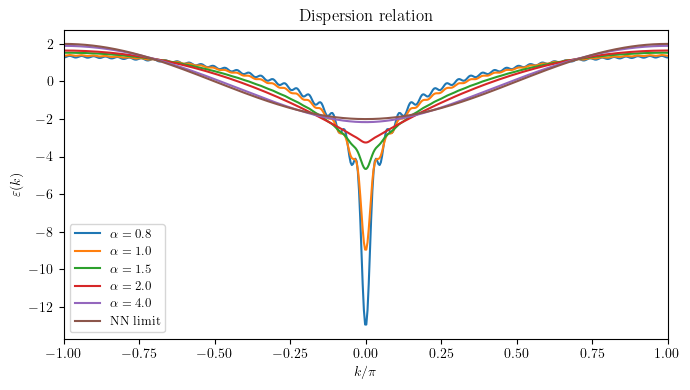

In [3]:
def dispersion(k, alpha, Rmax=50):
    """Non-interacting dispersion for 1D LR Hubbard chain."""
    eps = np.zeros_like(k, dtype=float)
    for r in range(1, Rmax + 1):
        eps -= 2.0 / r**alpha * np.cos(r * k)
    return eps

k = np.linspace(-np.pi, np.pi, 500)
alphas = [0.8, 1.0, 1.5, 2.0, 4.0, 10.0]  # alpha = 6.0 ≈ NN limit
labels = [fr'$\alpha={a}$' if a < 5 else 'NN limit' for a in alphas]

fig, ax = plt.subplots(figsize=(7, 4))
for a, lbl in zip(alphas, labels):
    ax.plot(k / np.pi, dispersion(k, a), label=lbl)
ax.set_xlabel(r'$k / \pi$')
ax.set_ylabel(r'$\varepsilon(k)$')
ax.set_title('Dispersion relation')
ax.legend(fontsize=9)
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dispersion_LR_1D.pdf')
plt.show()

## 2. Density of states $D(\varepsilon)$

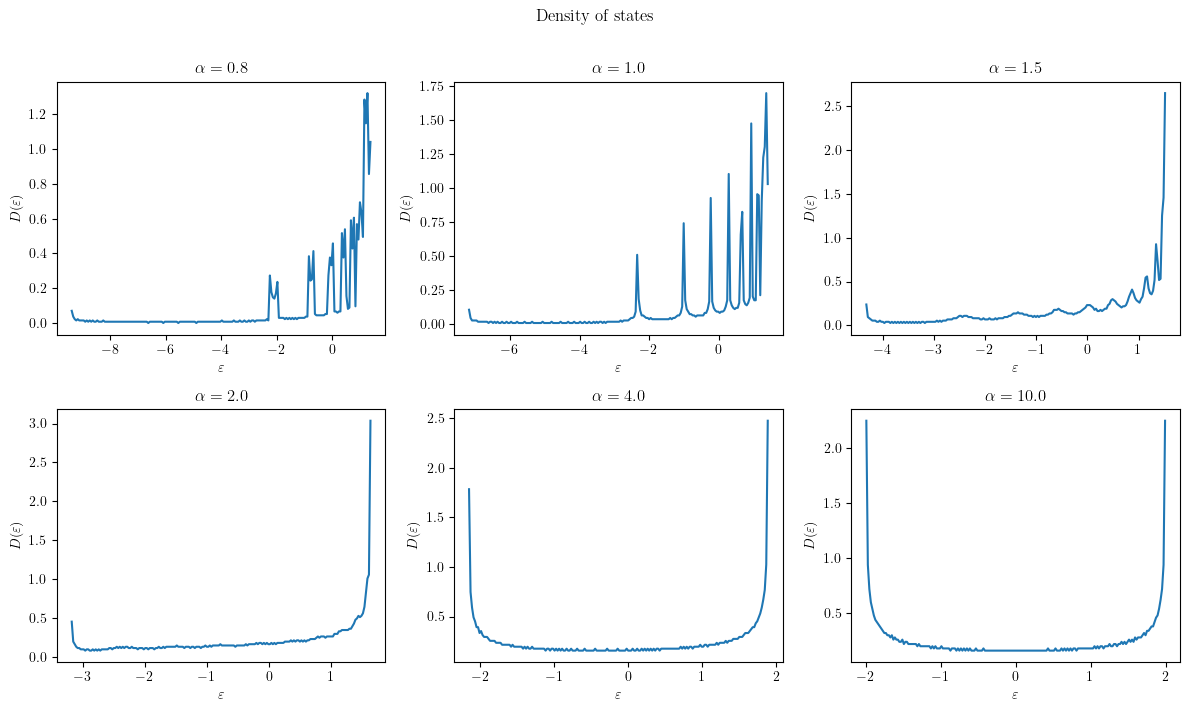

In [4]:
def dos(alpha, Rmax=20, n_k=5000, n_bins=200):
    """DOS via histogram of ε(k) over the Brillouin zone."""
    k = np.linspace(-np.pi, np.pi, n_k, endpoint=False)
    eps = dispersion(k, alpha, Rmax)
    counts, edges = np.histogram(eps, bins=n_bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=False)
for ax, a in zip(axes.flat, alphas):
    e, d = dos(a)
    ax.plot(e, d)
    ax.set_title(fr'$\alpha = {a}$')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel(r'$D(\varepsilon)$')
plt.suptitle('Density of states', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dos_LR_1D.pdf')
plt.show()

## 3. Hopping amplitude decay $t(r) = 1/r^\alpha$

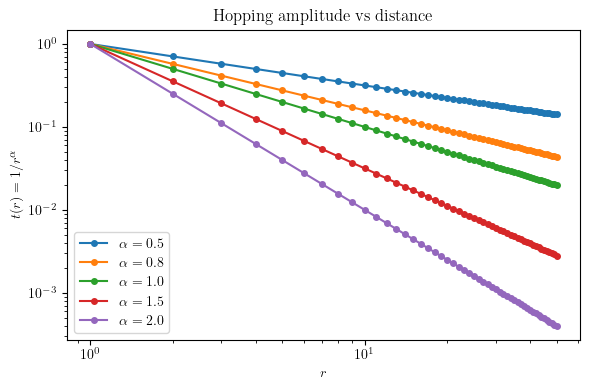

In [5]:
r = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(6, 4))
for a in [0.5, 0.8, 1.0, 1.5, 2.0]:
    ax.plot(r, 1.0 / r**a, 'o-', ms=4, label=fr'$\alpha={a}$')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$t(r) = 1/r^\alpha$')
ax.set_title('Hopping amplitude vs distance')
ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hopping_amplitudes_LR_1D.pdf')
plt.show()

## 4. Density calibration — find $\mu^*$ for $n_\sigma = 0.4$

Run a μ sweep at the target parameters and interpolate to find the chemical
potential that gives $n_\sigma = 0.4$.

> **Before running**: make sure the density-scan
> simulations on the cluster are submitted and retrieved. Set `DATA_BASE` or pass `base=` below.

In [6]:
# ---- Parameters for calibration scan ----
U       = -3.0
beta    = 70.0
L       = 50
alpha   = 2.0   # NN (Rmax=1) first
Rmax    = 1

# μ grid to scan (submit these with run_simulation.py --sweep-mu ...)
mu_range = [-0.60]

result = scan_density_vs_mu(
    U=U, beta=beta, L=L, mu_range=mu_range,
    alpha=alpha, Rmax=Rmax, sID=1, base=DATA_DIR
)

  μ=-0.6000  n=0.8000  n_up=0.4000


μ* for n_sigma = 0.4: -0.6000


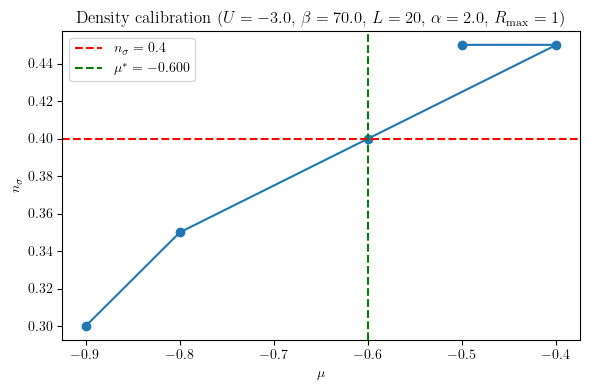

In [10]:
# Interpolate to find mu* for a target density
TARGET = 0.40               # density target value
TARGET_TYPE = 'n_sigma'     # 'n' for total density, 'n_sigma' for per-spin density

if TARGET_TYPE == 'n_sigma':
    vals = result['density_up']
    ylabel, label_str = r'$n_\sigma$', r'n_\sigma'
else:
    vals = result['density']
    ylabel, label_str = r'$n$', r'n'

mu_vals = result['mu']

# Deduplicate: density plateaus produce repeated values that break interp1d
_, unique_idx = np.unique(vals, return_index=True)
vals_u = vals[unique_idx]
mu_u = mu_vals[unique_idx]

if len(vals_u) < 2:
    print("Not enough data points — run the μ sweep first.")
elif TARGET < vals_u.min():
    print(f"Target {TARGET_TYPE}={TARGET} is below the scanned range (min={vals_u.min():.3f}).")
    print(f"Run simulations at more negative μ (below {mu_u[0]:.2f}) and extend mu_range.")
elif TARGET > vals_u.max():
    print(f"Target {TARGET_TYPE}={TARGET} is above the scanned range (max={vals_u.max():.3f}).")
    print(f"Run simulations at higher μ (above {mu_u[-1]:.2f}) and extend mu_range.")
else:
    f_interp = interp1d(vals_u, mu_u, kind='linear')
    mu_star = float(f_interp(TARGET))
    print(f"μ* for {TARGET_TYPE} = {TARGET}: {mu_star:.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(mu_u, vals_u, 'o-')
    ax.axhline(TARGET, color='r', ls='--', label=f'${label_str} = {TARGET}$')
    ax.axvline(mu_star, color='g', ls='--', label=f'$\\mu^* = {mu_star:.3f}$')
    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(ylabel)
    ax.set_title(fr'Density calibration ($U={U}$, $\beta={beta}$, $L={L}$, $\alpha={alpha}$, $R_{{\rm max}}={Rmax}$)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'density_calibration_NN.pdf')
    plt.show()